In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.formula.api import logit
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.feature_selection import RFE

In [2]:
df = pd.read_csv('D600 Task 3 Dataset 1 Housing Information.csv')
df

,ID,Price,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,...,RenovationQuality,LocalAmenities,TransportAccess,Fireplace,HouseColor,Garage,Floors,Windows,PreviousSalePrice,IsLuxury
0,4922,255614.8992,566.62,1.000000,4,779.42,20.56,5.62,39.46,10.08,...,4.93,4.44,4.55,Yes,Blue,No,1,13,181861.54230,0
1,5009,155586.0947,1472.34,1.000000,2,656.13,15.62,5.63,40.51,7.89,...,4.08,5.56,6.83,No,Green,No,1,17,50042.59757,0
2,4450,131050.8324,550.00,1.779354,3,754.57,12.47,9.20,48.38,23.74,...,4.26,8.07,8.48,Yes,Green,Yes,2,34,48400.34440,0
3,1070,151361.7125,941.81,2.035254,2,439.59,22.22,7.08,94.67,5.22,...,4.45,5.00,6.27,Yes,Red,No,1,14,84594.12145,0
4,400,113167.6128,550.00,1.064644,3,353.03,8.28,5.93,16.80,43.13,...,3.36,5.46,6.99,No,White,Yes,1,21,22934.59654,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,6987,307821.1758,550.00,2.111022,4,892.35,11.89,7.97,28.18,19.23,...,4.76,3.81,6.87,No,White,Yes,1,18,241131.63070,1
6996,6995,421368.8869,1726.12,4.056115,2,943.19,34.06,5.82,90.45,17.60,...,5.31,9.84,10.00,No,White,Yes,1,18,481604.80730,1
6997,6996,473382.5348,1026.36,2.077177,5,149.31,0.10,8.81,31.79,11.59,...,4.98,7.47,2.96,No,Green,No,1,13,380555.49390,1
6998,6998,343397.9756,2218.22,1.000000,4,526.81,11.18,9.20,15.21,3.96,...,4.68,7.66,6.12,No,Blue,Yes,1,10,442610.31710,0


In [5]:
#C1
categorical_cols = ['Fireplace', 'HouseColor', 'Garage', 'ID', 'IsLuxury']
continuous_df = df.drop(columns=categorical_cols)
y = continuous_df['Price']
X = continuous_df.drop(columns=['Price'])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled_df.head()

,SquareFootage,NumBathrooms,NumBedrooms,BackyardSpace,CrimeRate,SchoolRating,AgeOfHome,DistanceToCityCenter,EmploymentRate,PropertyTaxRate,RenovationQuality,LocalAmenities,TransportAccess,Floors,Windows,PreviousSalePrice
0,-1.132277,-1.187828,0.970213,0.957151,-0.591776,-0.700696,-0.230889,-0.615042,0.794367,0.681094,-0.037232,-0.562349,-0.733870,-0.438098,-0.363983,-0.552700
1,0.993926,-1.187828,-0.986989,0.516683,-0.865854,-0.695399,-0.197846,-0.797175,-0.109066,-1.104064,-0.468641,-0.140939,0.433066,-0.438098,0.084154,-1.262469
2,-1.171293,-0.369602,-0.008388,0.868372,-1.040621,1.195478,0.049814,0.521008,0.641205,0.741268,-0.377284,0.803473,1.277560,2.249618,1.988736,-1.271312
3,-0.251508,-0.100938,-0.986989,-0.256932,-0.499677,0.072604,1.506508,-1.019229,-0.501960,-0.101167,-0.280851,-0.351644,0.146450,-0.438098,-0.251949,-1.076429
4,-1.171293,-1.119960,-0.008388,-0.566178,-1.273088,-0.536502,-0.943973,2.133599,-1.600730,-0.482268,-0.834070,-0.178565,0.514957,-0.438098,0.532291,-1.408430


In [7]:
#D1
X = df.drop(columns=['Price', 'IsLuxury', 'Garage', 'Fireplace', 'HouseColor', 'ID'])
y = df['Price']

In [9]:
#D2
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_cleaned = pd.DataFrame(X_scaled, columns=X.columns)
X_cleaned['Price'] = y
X_cleaned.to_csv("cleaned_dataset.csv", index=False)

In [11]:
#D3
desc_stats = df[X.columns.tolist() + ['Price']].describe().T
print(desc_stats)

                       count           mean            std           min  \
SquareFootage         7000.0    1048.947459     426.010482    550.000000   
NumBathrooms          7000.0       2.131397       0.952561      1.000000   
NumBedrooms           7000.0       3.008571       1.021940      1.000000   
BackyardSpace         7000.0     511.507029     279.926549      0.390000   
CrimeRate             7000.0      31.226194      18.025327      0.030000   
SchoolRating          7000.0       6.942923       1.888148      0.220000   
AgeOfHome             7000.0      46.797046      31.779701      0.010000   
DistanceToCityCenter  7000.0      17.475337      12.024985      0.000000   
EmploymentRate        7000.0      93.711349       4.505359     72.050000   
PropertyTaxRate       7000.0       1.500437       0.498591      0.010000   
RenovationQuality     7000.0       5.003357       1.970428      0.010000   
LocalAmenities        7000.0       5.934579       2.657930      0.000000   
TransportAcc

In [13]:
#E1
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(X_pca.shape[1])])
pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
0,-0.906454,-0.633539,-0.274815,-1.531995,0.109145,-0.123291,1.592387,0.717741,-0.247255,-0.481445,-0.607733,-0.495821,-0.166348,0.852642,-0.097410,0.091630
1,-0.807884,-0.259993,0.686628,-0.866115,-1.687061,0.400225,-0.460930,-0.759108,-0.335376,-1.500496,0.252975,0.044270,0.451334,0.130488,-0.340759,-0.703467
2,-0.261683,3.055160,1.679027,-1.781387,0.803494,0.451694,0.926338,-0.064890,-0.318595,0.611187,-0.041432,0.799300,0.339714,-0.798653,0.214044,-0.199576
3,-1.059663,-0.541531,0.124366,-0.173473,-0.174354,0.232971,-0.340012,-1.533564,-0.345280,-0.276606,-1.234000,0.787661,0.367391,-0.138354,-0.136862,-0.227351
4,-2.172205,0.160409,1.047683,-0.590920,-0.127632,-1.020908,-0.004908,-0.100600,-1.447254,0.932776,2.301490,0.351517,0.475118,0.297867,-0.714096,-0.276095


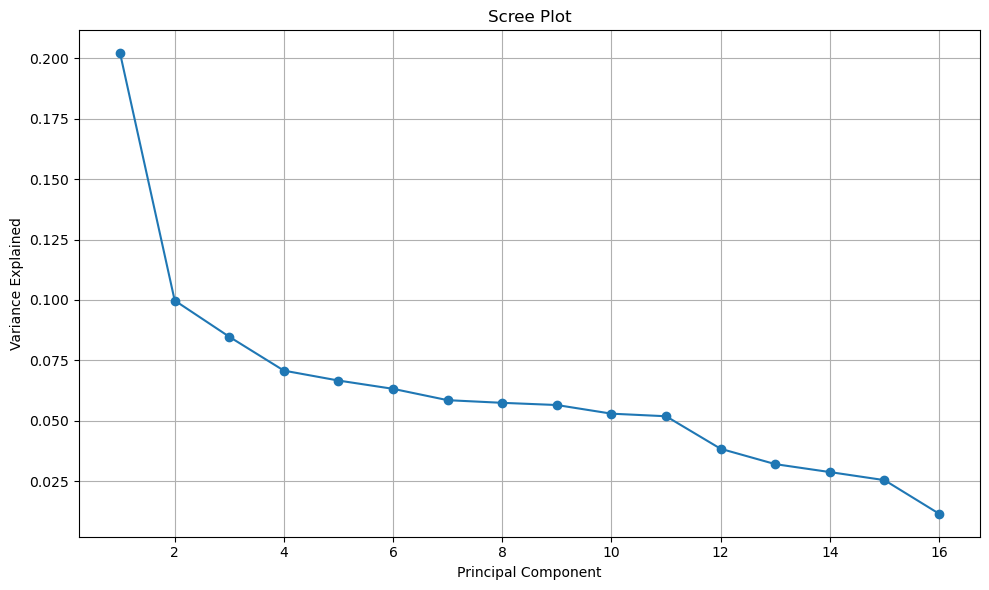

In [15]:
#E2
explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_, marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.grid(True)
plt.tight_layout()
plt.savefig("scree_plot.png")
plt.show()

In [17]:
#E3
variance_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_variance))],
    'Variance Explained': explained_variance,
    'Cumulative Variance': explained_variance.cumsum()
})
print(variance_df)

   Principal Component  Variance Explained  Cumulative Variance
0                  PC1            0.202100             0.202100
1                  PC2            0.099755             0.301854
2                  PC3            0.084733             0.386587
3                  PC4            0.070717             0.457304
4                  PC5            0.066607             0.523911
5                  PC6            0.063173             0.587085
6                  PC7            0.058477             0.645562
7                  PC8            0.057381             0.702943
8                  PC9            0.056470             0.759413
9                 PC10            0.052891             0.812304
10                PC11            0.051821             0.864125
11                PC12            0.038344             0.902469
12                PC13            0.031992             0.934460
13                PC14            0.028706             0.963167
14                PC15            0.0253

In [19]:
X_pca_selected = X_pca[:, :10] 

In [21]:
#E4
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=X.columns)
print("Top 10 Principal Component Loadings:")
print(loadings.iloc[:, :10].round(3))

Top 10 Principal Component Loadings:
                        PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8  \
SquareFootage         0.325 -0.011 -0.158  0.246 -0.071  0.196 -0.129 -0.229   
NumBathrooms          0.282 -0.012 -0.175  0.235 -0.100  0.208 -0.064 -0.135   
NumBedrooms           0.290 -0.009 -0.110 -0.010  0.322 -0.375  0.321  0.333   
BackyardSpace         0.095  0.012  0.028 -0.097 -0.285  0.710  0.482  0.275   
CrimeRate            -0.112  0.043 -0.039  0.592  0.033  0.001 -0.152  0.646   
SchoolRating          0.382 -0.017 -0.091 -0.231  0.206 -0.121 -0.003  0.028   
AgeOfHome            -0.143 -0.010 -0.079  0.154  0.508  0.354 -0.221 -0.359   
DistanceToCityCenter -0.200  0.031  0.021  0.059  0.443  0.265 -0.220  0.247   
EmploymentRate        0.129 -0.015  0.020 -0.584  0.249  0.232 -0.252  0.307   
PropertyTaxRate      -0.143  0.002  0.039  0.146  0.456  0.025  0.674 -0.192   
RenovationQuality     0.414 -0.002 -0.054 -0.003  0.162  0.097 -0.041  0.008   
Loc

In [23]:
#F1
X_train, X_test, y_train, y_test = train_test_split(
    X_pca_selected, y, test_size=0.2, random_state=42)
X_train_df = pd.DataFrame(X_train, columns=[f"PC{i+1}" for i in range(X_train.shape[1])])
X_test_df = pd.DataFrame(X_test, columns=[f"PC{i+1}" for i in range(X_test.shape[1])])
train_final = pd.concat([X_train_df, y_train.reset_index(drop=True)], axis=1)
test_final = pd.concat([X_test_df, y_test.reset_index(drop=True)], axis=1)
train_final.to_csv("train_pca_set.csv", index=False)
test_final.to_csv("test_pca_set.csv", index=False)

In [25]:
#F2
lr = LinearRegression()
rfe = RFE(estimator=lr, n_features_to_select=5)
rfe.fit(X_train_df, y_train)
selected_mask = rfe.support_
selected_features = X_train_df.columns[selected_mask]
X_train_selected = X_train_df[selected_features]
X_test_selected = X_test_df[selected_features]
lr_final = LinearRegression()
lr_final.fit(X_train_selected, y_train)
intercept = lr_final.intercept_
coefficients = pd.Series(lr_final.coef_, index=selected_features)
print("Intercept:", intercept)
print("Coefficients:\n", coefficients)

Intercept: 308079.5681255838
Coefficients:
 PC1    62360.802452
PC3   -24161.849459
PC4    30341.744687
PC5     5573.956252
PC9    -4296.960717
dtype: float64


In [27]:
#F3
y_train_pred = lr_final.predict(X_train_selected)
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)
print("Training MSE:", mse_train)
print("Training R²:", r2_train)

Training MSE: 8227380412.490102
Training R²: 0.6406099569110018


In [29]:
#F4
y_test_pred = lr_final.predict(X_test_selected)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)
print("Test MSE:", mse_test)
print("Test R²:", r2_test)

Test MSE: 8113852373.206835
Test R²: 0.6166347619728878


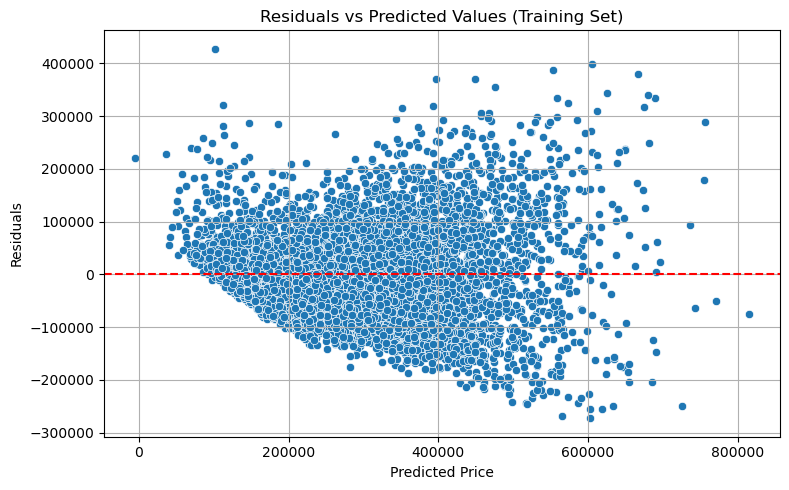

In [31]:
#G3-1
y_train_pred = lr_final.predict(X_train_selected)
residuals = y_train - y_train_pred
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_train_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values (Training Set)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
#G3-2
from statsmodels.stats.stattools import durbin_watson
dw_stat = durbin_watson(residuals)
print("Durbin-Watson Statistic:", round(dw_stat, 3))

Durbin-Watson Statistic: 1.981


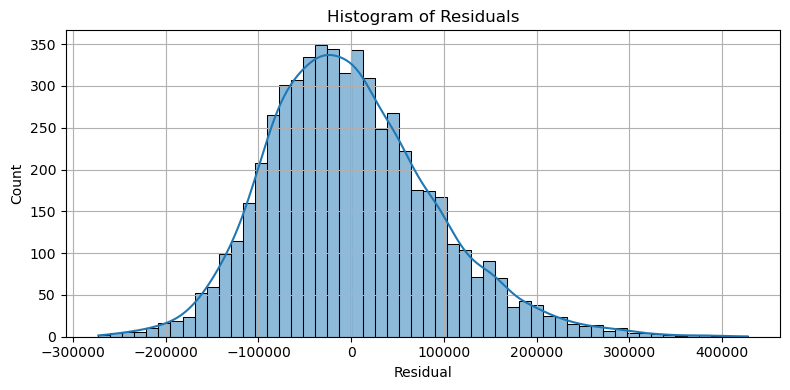

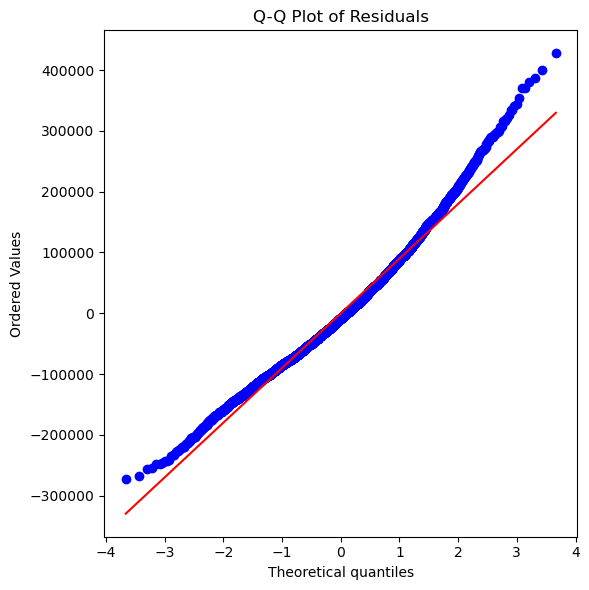

In [35]:
#G3-3
import scipy.stats as stats
plt.figure(figsize=(8, 4))
sns.histplot(residuals, kde=True)
plt.title("Histogram of Residuals")
plt.xlabel("Residual")
plt.grid(True)
plt.tight_layout()
plt.show()
plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.tight_layout()
plt.show()

In [37]:
#G3-4
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_df_scaled = pd.DataFrame(X_scaled, columns=X.columns)
vif_data = pd.DataFrame()
vif_data['Feature'] = X_df_scaled.columns
vif_data['VIF'] = [variance_inflation_factor(X_df_scaled.values, i) for i in range(X_df_scaled.shape[1])]
print(vif_data)

                 Feature       VIF
0          SquareFootage  1.870729
1           NumBathrooms  1.535817
2            NumBedrooms  1.722388
3          BackyardSpace  1.022725
4              CrimeRate  1.049312
5           SchoolRating  1.575954
6              AgeOfHome  1.045519
7   DistanceToCityCenter  1.083262
8         EmploymentRate  1.068036
9        PropertyTaxRate  1.057331
10     RenovationQuality  1.677460
11        LocalAmenities  1.337921
12       TransportAccess  1.339437
13                Floors  1.545063
14               Windows  1.544116
15     PreviousSalePrice  3.337671


In [39]:
#G4
intercept = lr_final.intercept_
coefficients = pd.Series(lr_final.coef_, index=selected_features)
print("Intercept (β₀):", intercept)
print("Coefficient Estimates:")
print(coefficients)

Intercept (β₀): 308079.5681255838
Coefficient Estimates:
PC1    62360.802452
PC3   -24161.849459
PC4    30341.744687
PC5     5573.956252
PC9    -4296.960717
dtype: float64
